# Setup

In [4]:
import gc
import os
import sys
import logging
import warnings
from pathlib import Path
import matplotlib as mpl
import pickle
import math
from itertools import combinations
import session_info

SRCDIR = Path('../../..')
HOMEDIR = SRCDIR / '..'
PLOTDIR = HOMEDIR / "plots" / "kennedi_xenium"
DATADIR = HOMEDIR / "data" / "processed" / "spatial" / "Xenium" / "kennedi_flu"
if not str(SRCDIR) in sys.path:
    sys.path.insert(0, str(SRCDIR))

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", DeprecationWarning)

from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

# import spatialdata as sd
# import spatialdata_plot as sdp

%matplotlib inline
# R_preload()
mpl.rcdefaults()
plt.rcParams["figure.figsize"] = (8, 8)
gc.collect()

session_info.show()

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/ome_zarr/writer.py:967: DeprecationWarning: Call to deprecated class Scaler. (Downsampling via the `Scaler` class has been deprecated. Please use the `scale_factors` argument instead.) -- Deprecated since version 0.14.0.
/mnt/DATA/home/ethung/projects/spatial_seq/.pi

In [5]:
niche_key = "cellcharter_k12"
celltype_key = "LabelTransfer_OT"
sample1 = "Ctrl_D14_2"
CORES = 10

adata = sc.read_h5ad(DATADIR / "integrated.h5ad")
adata

AnnData object with n_obs × n_vars = 4654531 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'Slide', 'Sample', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Genotype', 'Timepoint', 'cellcharter_k3', 'cellcharter_k6', 'cellcharter_k12', 'LabelTransfer_OT', 'Groups'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'LabelTransfer_OT_nhood_enrichment', 'PCA', 'UMAP', 'X_pca', 'cellcharter_k12_LabelTransfer_OT_enrichment', 'cellcharter_k12_nhood_enrichment', 'cellcharter_k6_LabelTransfer_OT_enrichment', 'cellcharter_k6_nhood_enrichment', 'dendrogram

# Label DEGs

In [ ]:
%%capture
RUN = False

if RUN is True:
    sc.tl.rank_genes_groups(
        adata, groupby=celltype_key,
        use_raw=False, layer="normalized",
        method="wilcoxon",
        key="LabelTransfer_DEGs"
    )

# plot DEGs
f, ax = plt.subplots(1, 1, figsize=(80, 10), layout="constrained")
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby=celltype_key,
    n_genes=10,
    values_to_plot="logfoldchanges",
    cmap="bwr",
    colorbar_title="log fold change",
    ax=ax, show=False,
    vmin=-4,
    vmax=4,
)

f.savefig(PLOTDIR / "overview", "Celltype-DEGs.jpg")

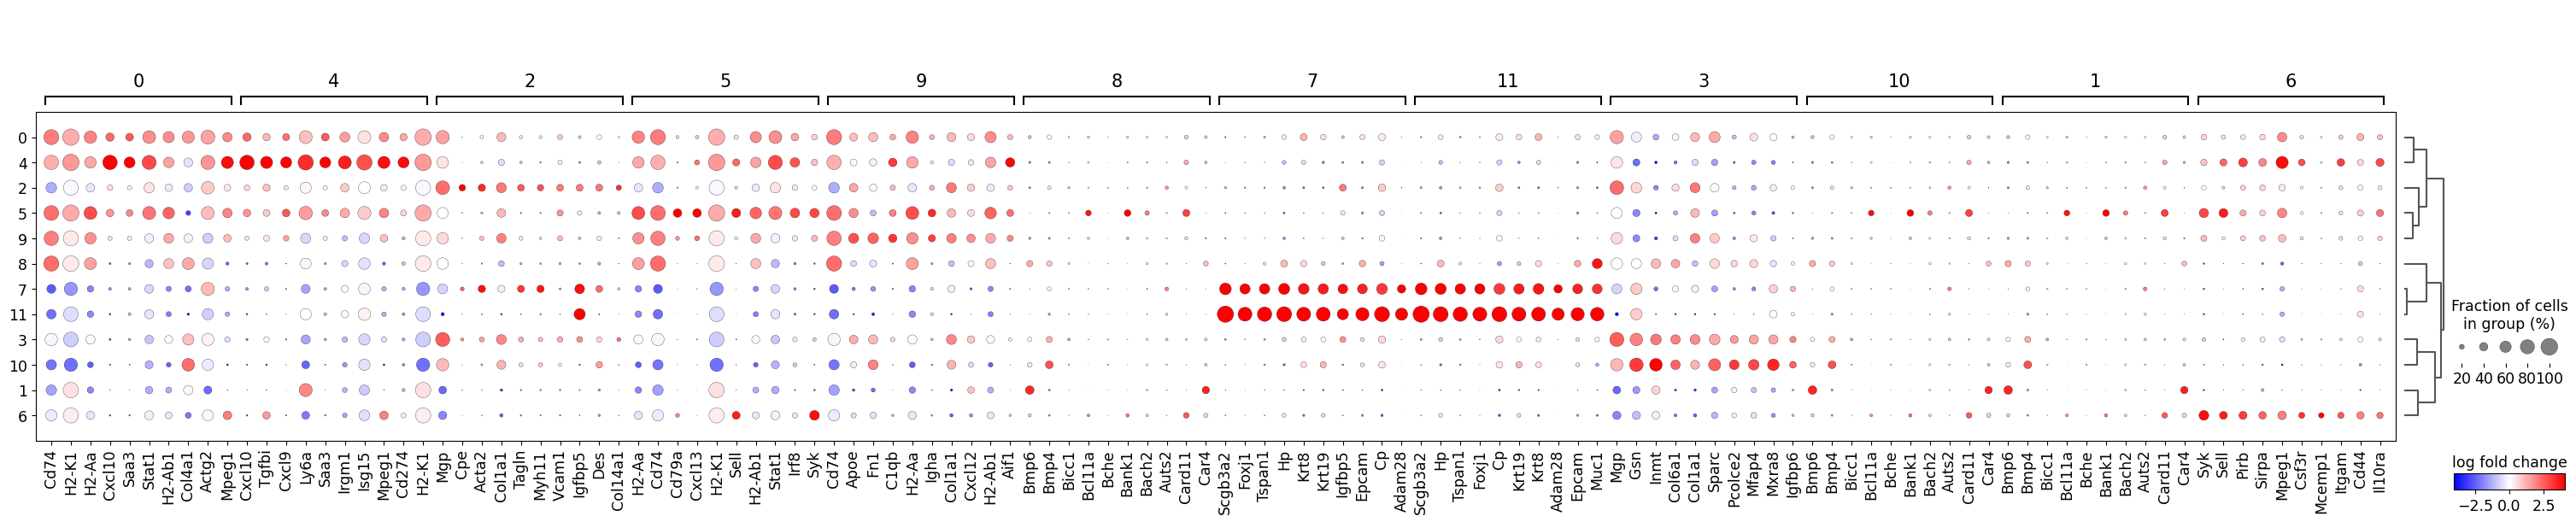

In [55]:
# %%capture
RUN = False

if RUN is True:
    sc.tl.rank_genes_groups(
        adata, groupby=niche_key,
        use_raw=False, layer="normalized",
        method="wilcoxon",
        key="Niche_DEGs"
    )

# plot DEGs
f, ax = plt.subplots(1, 1, figsize=(30, 6), layout="constrained")
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby=niche_key,
    n_genes=10,
    values_to_plot="logfoldchanges",
    cmap="bwr",
    colorbar_title="log fold change",
    ax=ax, show=False,
    vmin=-4,
    vmax=4,
)

f.savefig(PLOTDIR / "overview" / f"Niche-{niche_key}-DEGs.jpg")

# Comparison DEGs

In [6]:
import decoupler as dc

### sample pseudobulk

In [2]:
relevant_metadata = [
    "Sample", "Slide", "Groups", "Genotype", "Timepoint",
]

In [30]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col="Sample",
    groups_col="Sample",
    mode="sum",
)
pdata

AnnData object with n_obs × n_vars = 18 × 480
    obs: 'Sample', 'genomic_control_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'region', 'Slide', 'Genotype', 'Timepoint', 'Groups', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    layers: 'psbulk_props'

In [ ]:
# Store raw counts in layers
pdata.layers["counts"] = pdata.X.copy()

# Normalize, scale and compute pca
Normalize(pdata)
PCA(pdata, gene_mask=None, key="X_pca", comp=17)

# Return raw counts to X
dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)
dc.tl.rankby_obsm(pdata, key="X_pca", obs_keys=relevant_metadata)

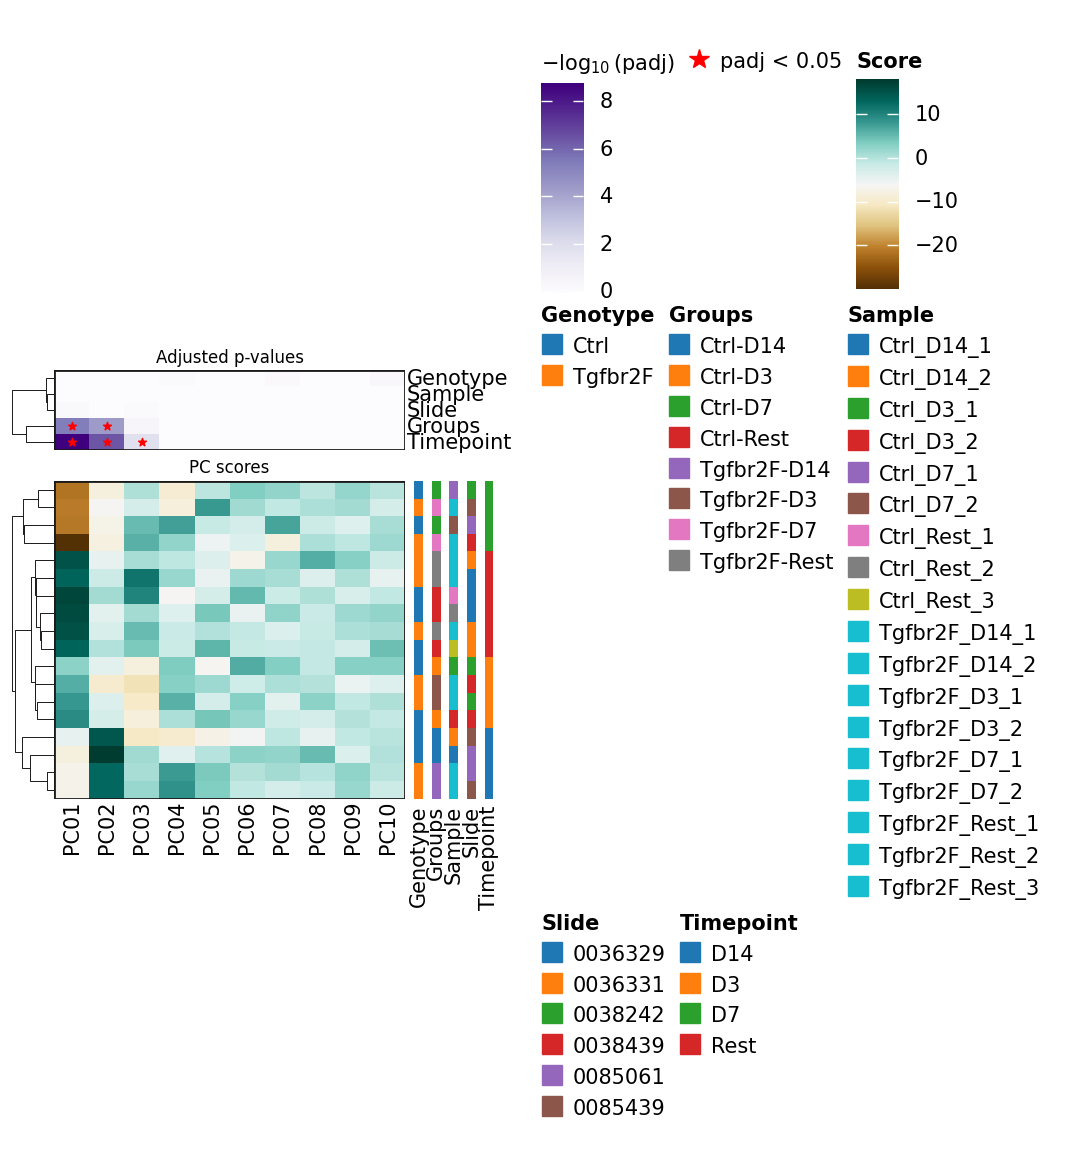

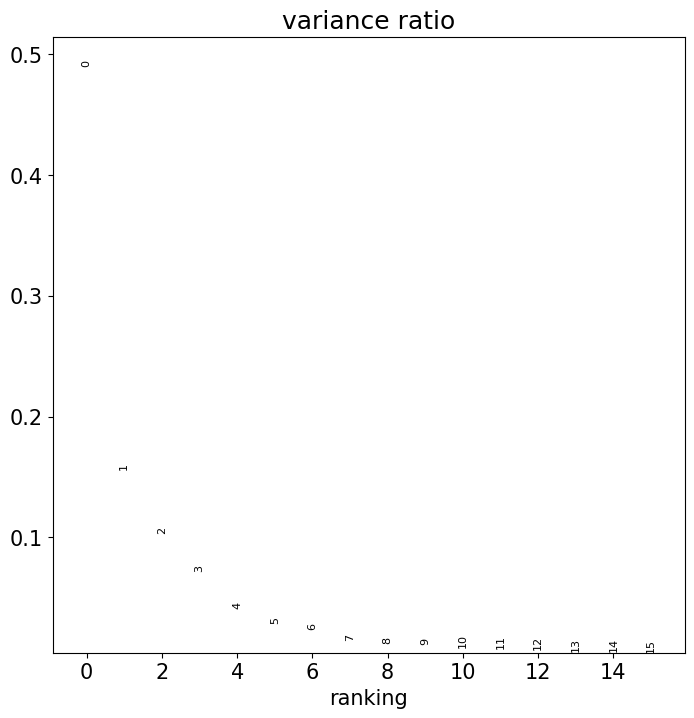

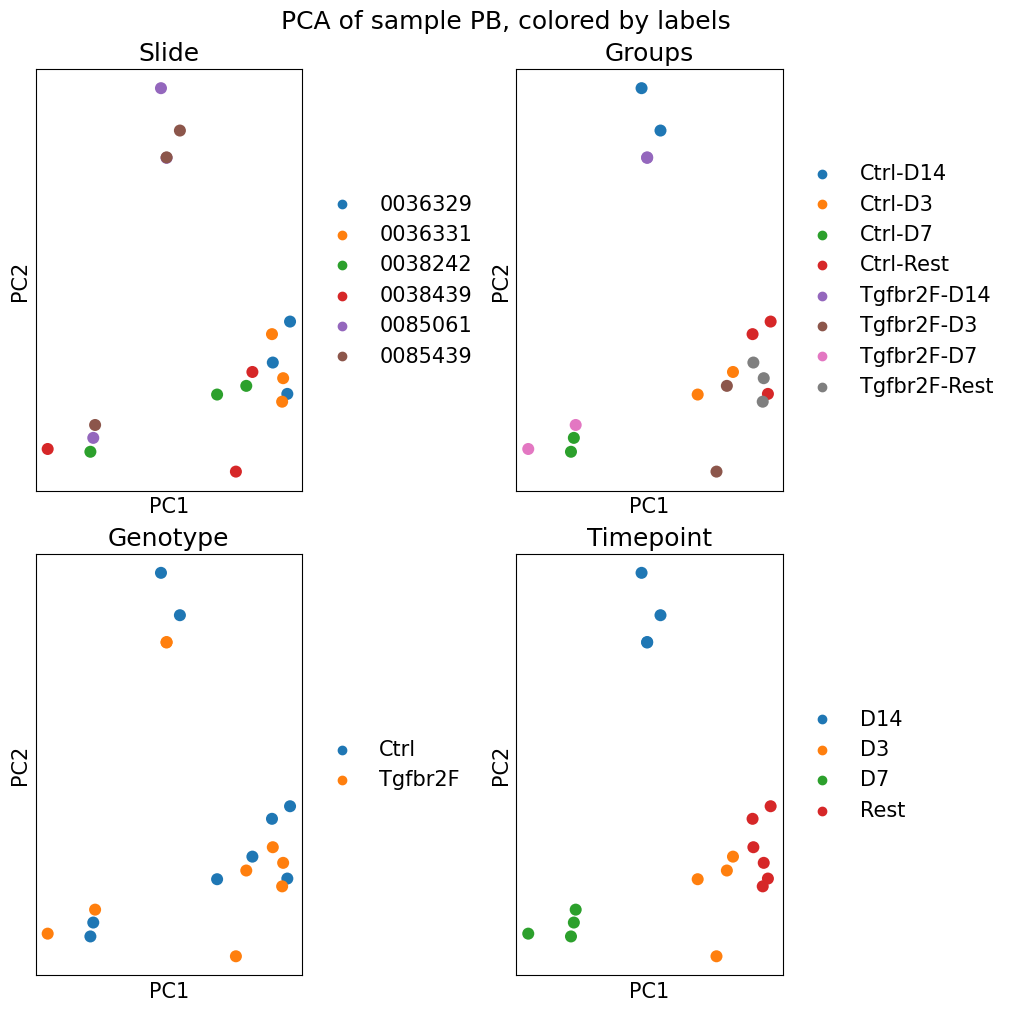

In [51]:
plt.rcParams.update({'font.size': 15})

sc.pl.ranking(pdata, "uns", "variance_ratio", dictionary="X_pca", n_points=15)

f,axs = plt.subplots(2,2, figsize=(10,10), layout="constrained")
axs = axs.flatten()
for i,col in enumerate(relevant_metadata[1:]):
    sc.pl.pca(
        pdata,
        color=col,
        size=300,
        frameon=True,
        ax=axs[i], show=False
    )
f.suptitle("PCA of sample PB, colored by labels")

dc.pl.obsm(adata=pdata, return_fig=True, nvar=10, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

/tmp/ipykernel_1231291/2446354248.py:17: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.


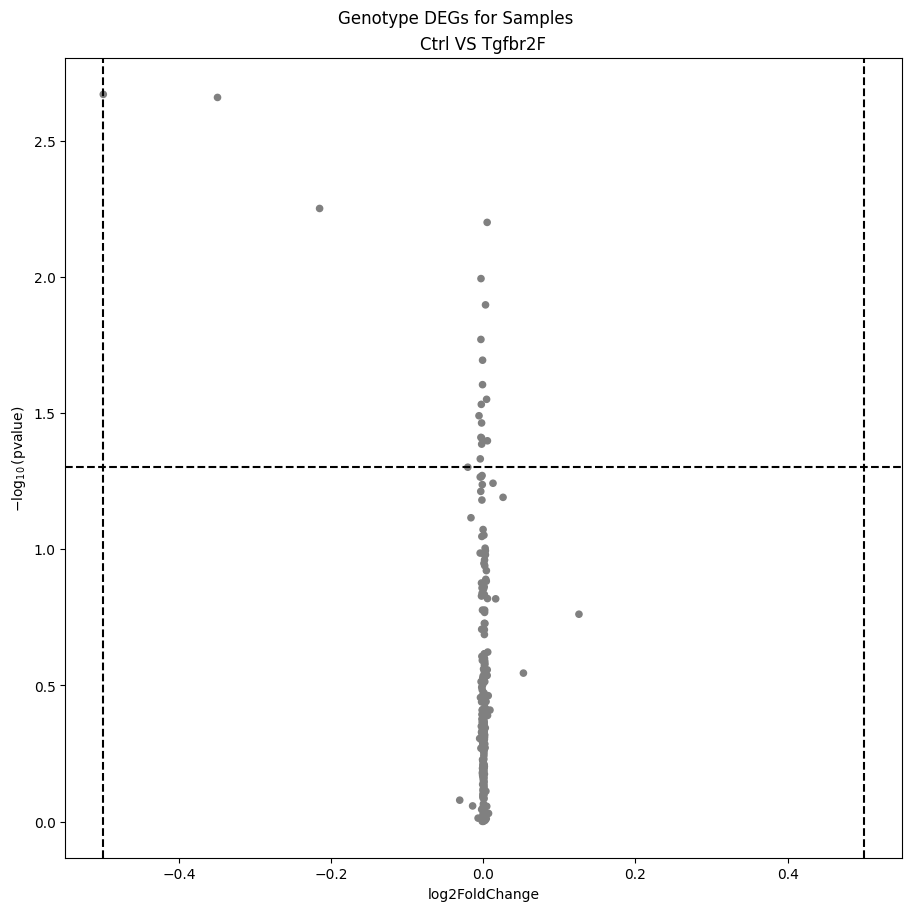

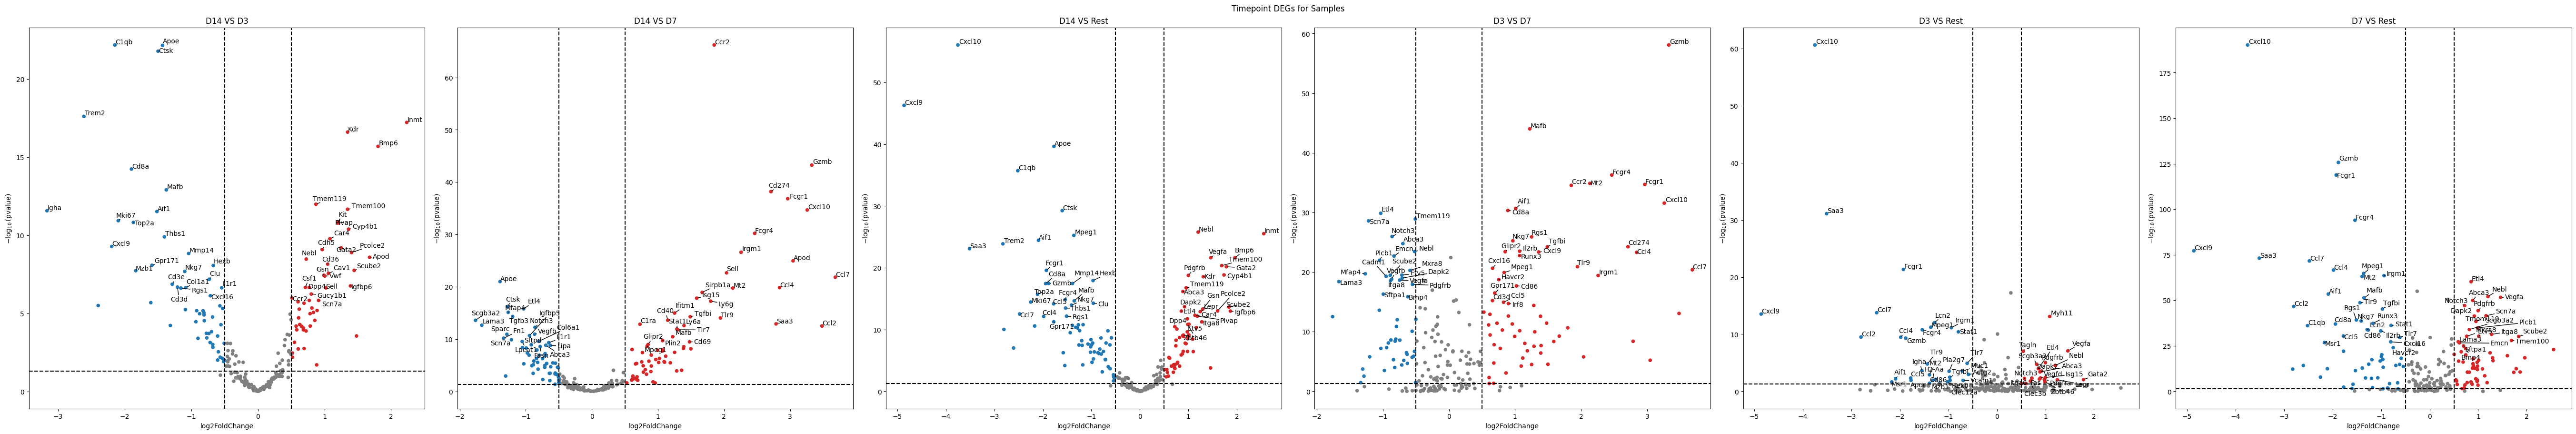

In [40]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats


# filter for low quality genes
dc.pp.filter_by_expr(
    adata=pdata, group="Timepoint",
    min_count=10, min_total_count=15, large_n=10, min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=pdata, min_prop=0.1, min_smpls=2,
)

# Build DESeq2 object
inference = DefaultInference(n_cpus=CORES)
dds = DeseqDataSet(
    adata=pdata,
    design_factors=["Genotype", "Timepoint"],
    refit_cooks=True,
    inference=inference,
    quiet=True
)
dds.deseq2()

for category in ["Genotype", "Timepoint"]:
    # generate plots for each comparison
    n_plots = math.comb(len(pdata.obs[category].cat.categories), 2)
    f, axs = plt.subplots(1, n_plots, figsize=(n_plots*9, 9), layout="constrained")   
    if n_plots == 1:
        axs = [axs]

    
    for i,contrast in enumerate(list(combinations(pdata.obs[category].cat.categories, 2))):
        # run Wald test; format: column, treatment, control
        ds = DeseqStats(dds, contrast=[category, *(contrast[::-1])], inference=inference, quiet=True)
        ds.summary()
        ds.lfc_shrink(coeff=f"{category}[T.{contrast[1]}]")
        
        # plot results
        results_df = ds.results_df
        dc.pl.volcano(
            results_df, x="log2FoldChange", y="pvalue",
            top=50, ax=axs[i])
        axs[i].set_title(f"{contrast[0]} VS {contrast[1]}")

    f.suptitle(f"{category} DEGs for Samples")
    f.savefig(PLOTDIR / "DEGs" / f"SAMPLE-{category}-PB_DEGs")


### celltype pseudobulk

In [52]:
relevant_metadata = [
    "LabelTransfer_OT", "Sample", "Slide", "Groups", "Genotype", "Timepoint",
]

In [53]:
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col="Sample",
    groups_col=celltype_key,
    mode="sum",
)

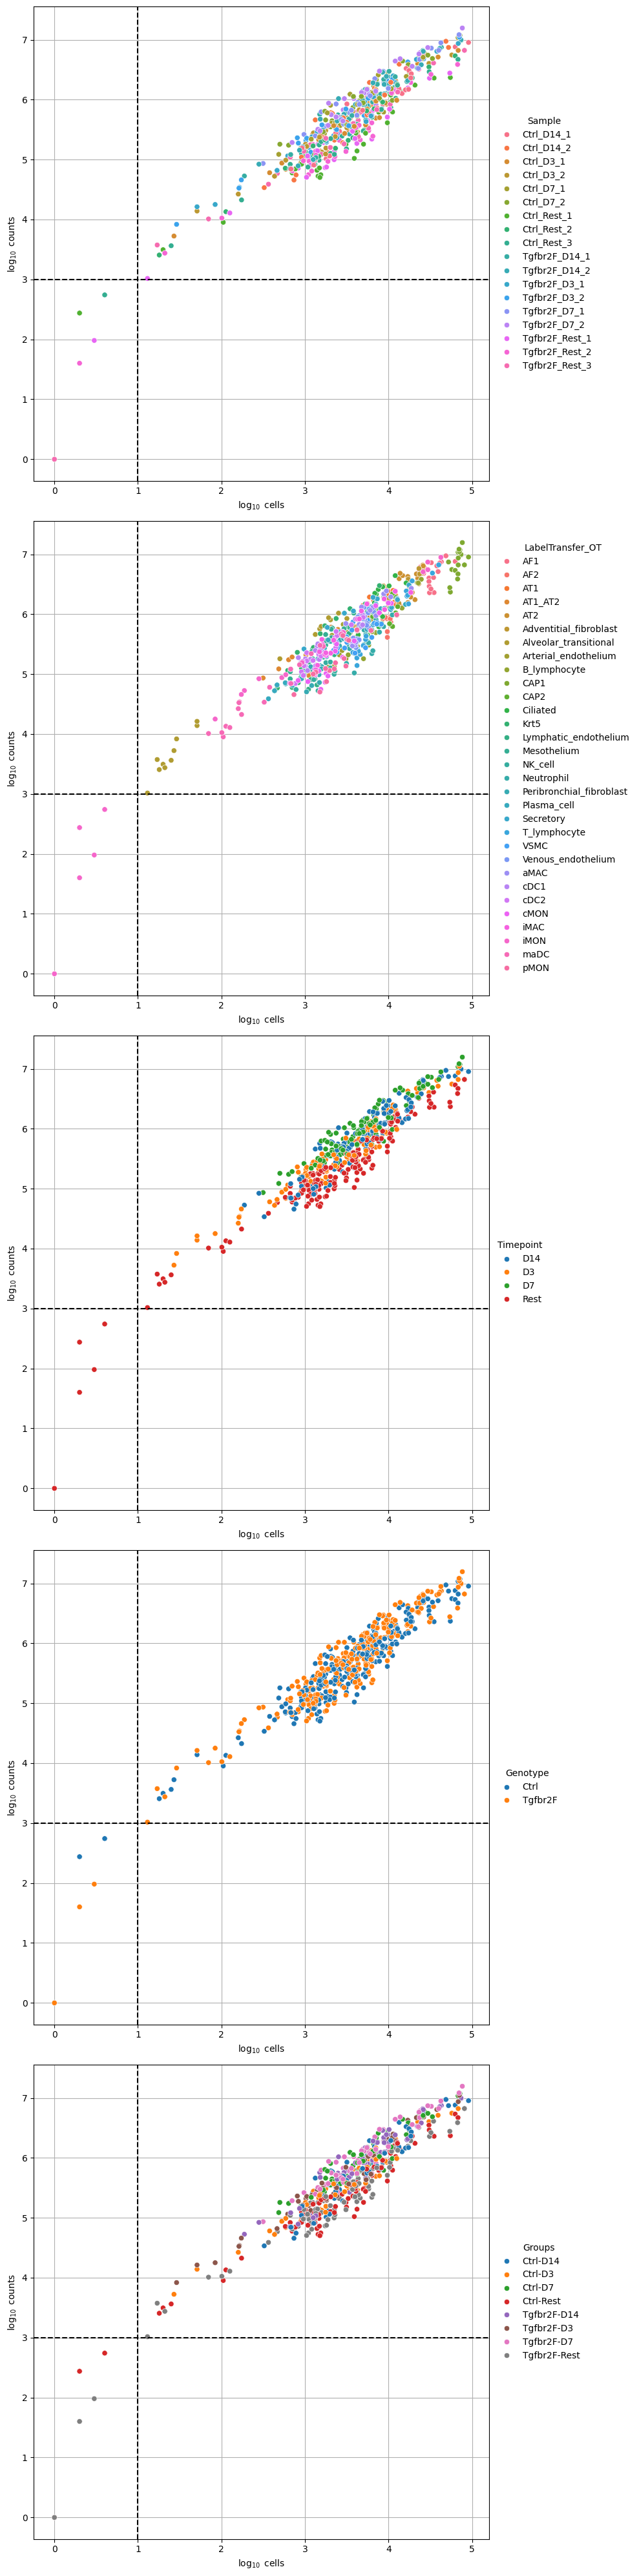

In [73]:
dc.pl.filter_samples(
    adata=pdata,
    groupby=["Sample", celltype_key, "Timepoint", "Genotype", "Groups"],
    min_cells=10,
    min_counts=1000,
    figsize=(10, 40),
)

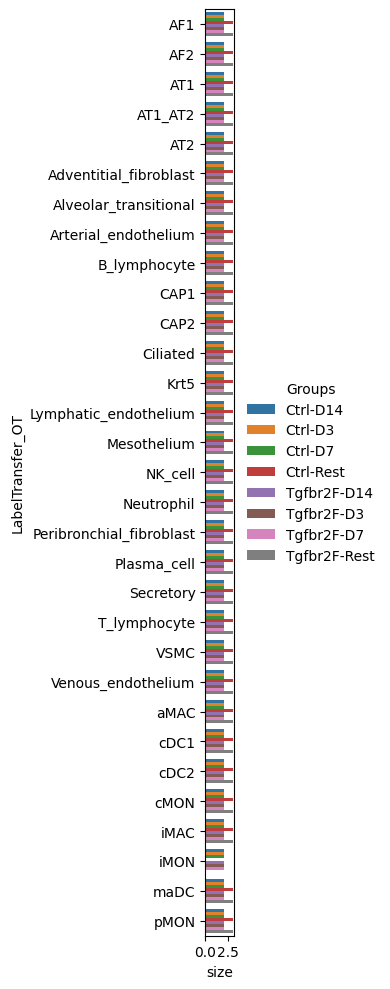

In [74]:
dc.pp.filter_samples(pdata, min_cells=10, min_counts=1000)
dc.pl.obsbar(adata=pdata, y=celltype_key, hue="Groups", figsize=(4, 10))

In [76]:
# Store raw counts in layers
pdata.layers["counts"] = pdata.X.copy()

# Normalize, scale and compute pca
Normalize(pdata)
PCA(pdata, gene_mask=None, key="X_pca")

# Return raw counts to X
dc.pp.swap_layer(adata=pdata, key="counts", inplace=True)
dc.tl.rankby_obsm(pdata, key="X_pca", obs_keys=relevant_metadata)

Saving normalized counts in layer 'normalized'.
Setting layer to normalized.
Starting PCA with gene mask None at 50 comps, saved at .obsm[X_pca].


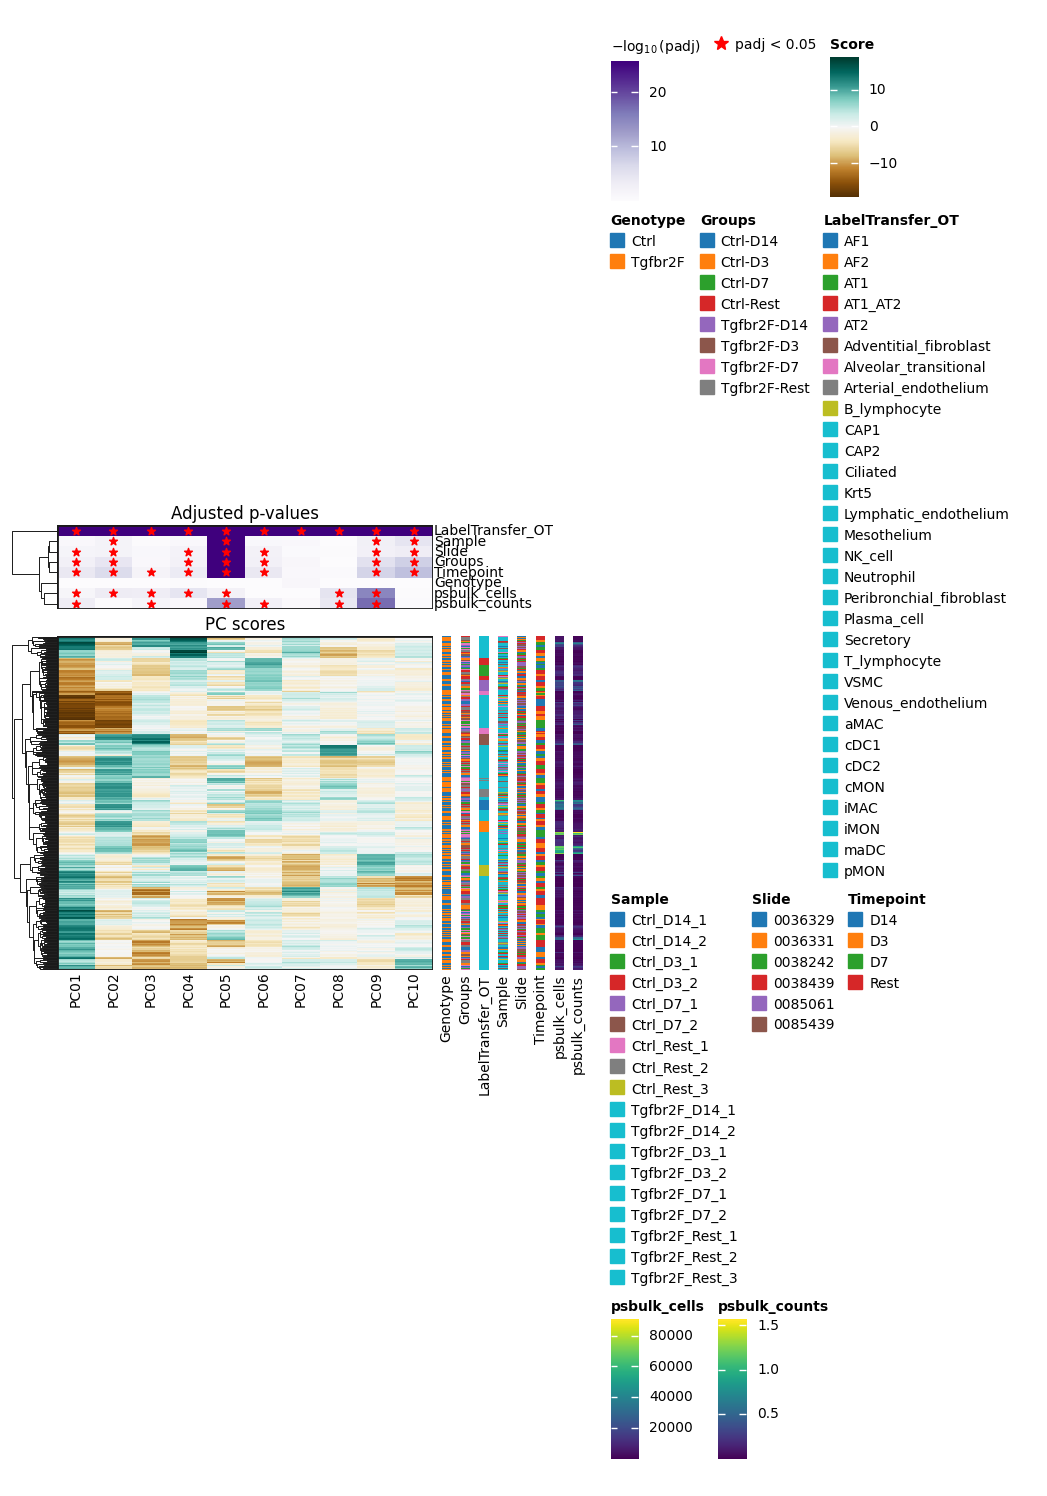

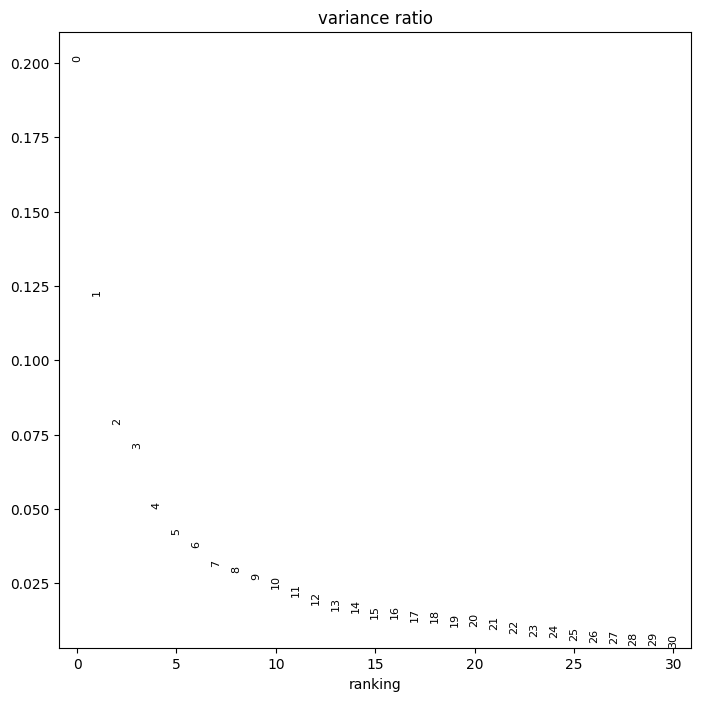

In [77]:
sc.pl.ranking(pdata, "uns", "variance_ratio", dictionary="X_pca")
dc.pl.obsm(adata=pdata, return_fig=True, nvar=10, titles=["PC scores", "Adjusted p-values"], figsize=(10, 5))

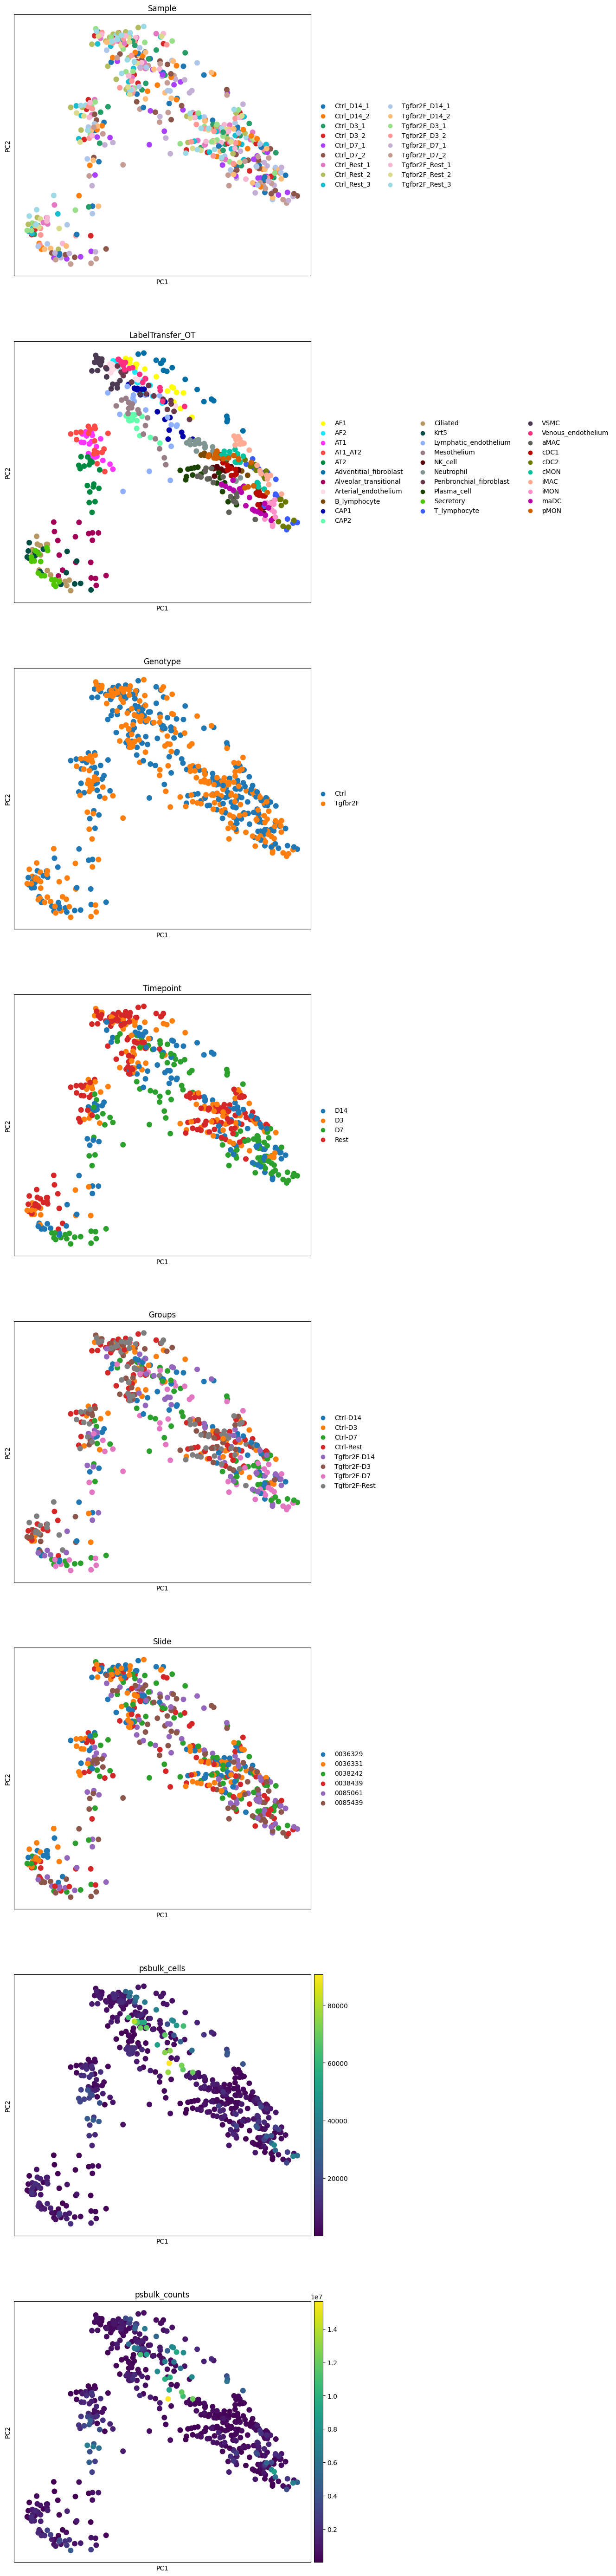

In [78]:
sc.pl.pca(
    pdata,
    color=relevant_metadata,
    ncols=1,
    size=300,
    frameon=True,
)

Celltype DEG Volcanos: 100%|██████████| 2/2 [00:47<00:00, 23.79s/it]


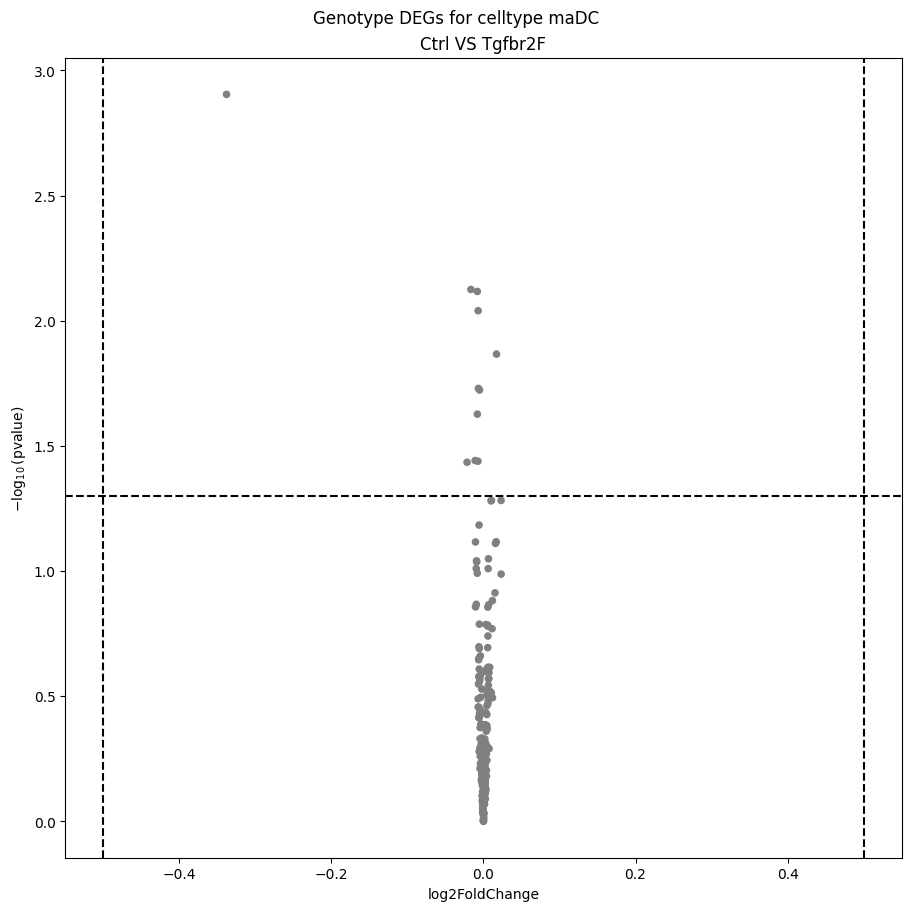

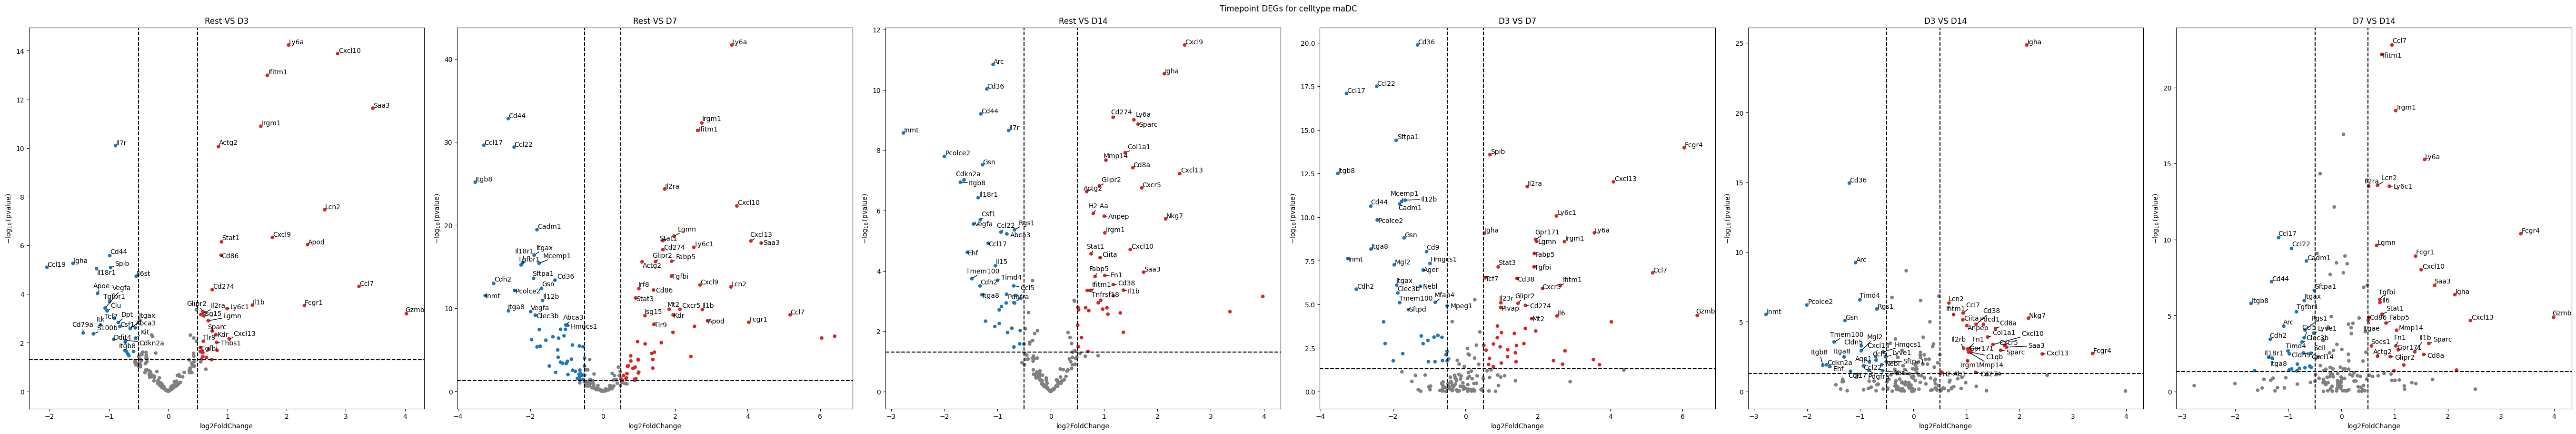

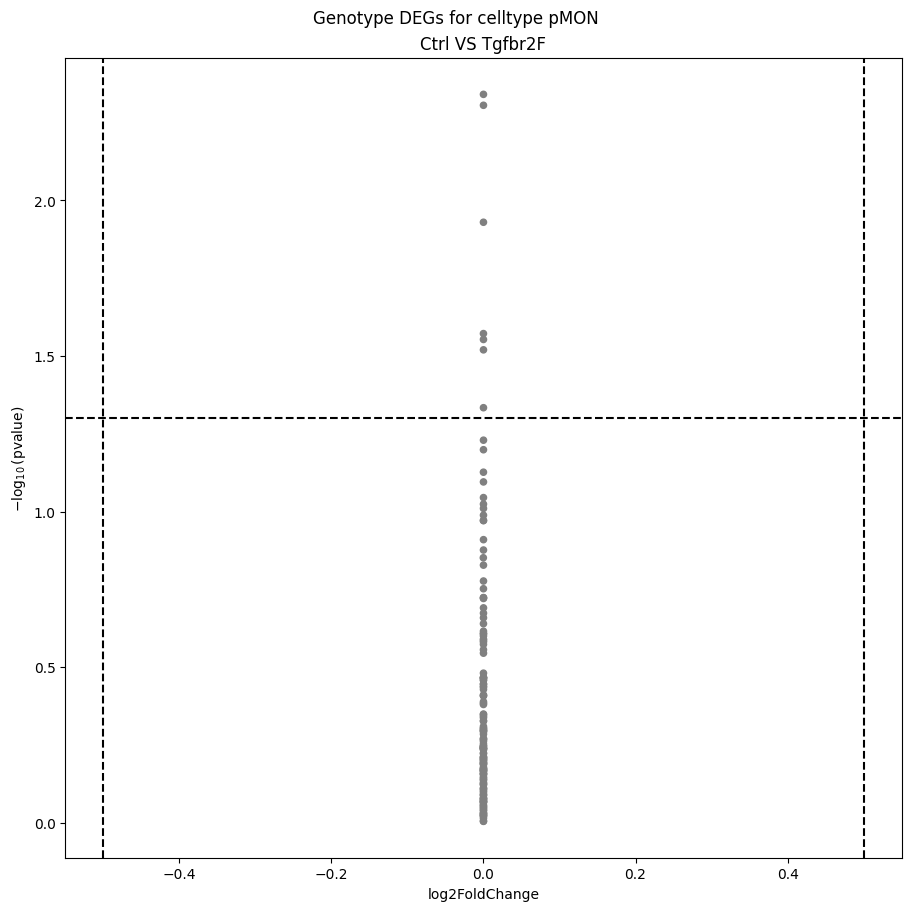

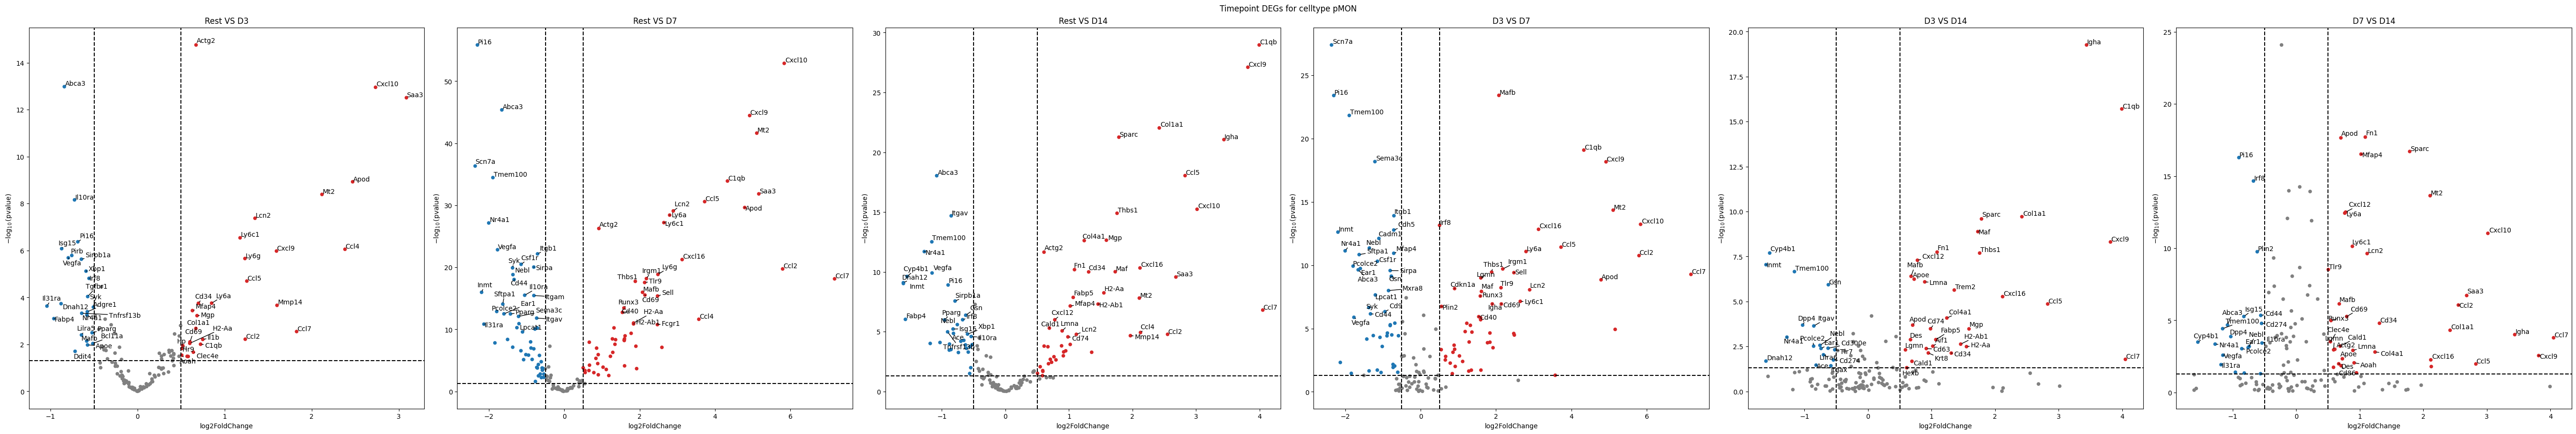

In [110]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

for ct in tqdm(pdata.obs["LabelTransfer_OT"].unique()[-2:], desc="Celltype DEG Volcanos"):
    ctdata = pdata[pdata.obs[celltype_key] == ct].copy()

    # filter for low quality genes
    dc.pp.filter_by_expr(
        adata=ctdata, group="Timepoint",
        min_count=10, min_total_count=15, large_n=10, min_prop=0.7,
    )
    dc.pp.filter_by_prop(
        adata=ctdata, min_prop=0.1, min_smpls=2,
    )

    # Build DESeq2 object
    inference = DefaultInference(n_cpus=CORES)
    dds = DeseqDataSet(
        adata=ctdata,
        design_factors=["Genotype", "Timepoint"],
        refit_cooks=True,
        inference=inference,
        quiet=True
    )
    dds.deseq2()

    for category in ["Genotype", "Timepoint"]:
        # generate plots for each comparison
        n_plots = math.comb(len(pdata.obs[category].cat.categories), 2)
        f, axs = plt.subplots(1, n_plots, figsize=(n_plots*9, 9), layout="constrained")   
        if n_plots == 1:
            axs = [axs]

        
        for i,contrast in enumerate(list(combinations(pdata.obs[category].cat.categories, 2))):
            # run Wald test; format: column, treatment, control
            ds = DeseqStats(dds, contrast=[category, *(contrast[::-1])], inference=inference, quiet=True)
            ds.summary()
            ds.lfc_shrink(coeff=f"{category}[T.{contrast[1]}]")
            
            # plot results
            results_df = ds.results_df
            dc.pl.volcano(
                results_df, x="log2FoldChange", y="pvalue",
                top=50, ax=axs[i])
            axs[i].set_title(f"{contrast[0]} VS {contrast[1]}")

        f.suptitle(f"{category} DEGs for celltype {ct}")
        f.savefig(PLOTDIR / "DEGs" / f"{category}-{ct}-PB_DEGs")


# Save/Load

In [29]:
# save
adata.write(DATADIR / "integrated.h5ad")
adata

AnnData object with n_obs × n_vars = 4654531 × 480
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels', 'Slide', 'Sample', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Genotype', 'Timepoint', 'cellcharter_k3', 'cellcharter_k6', 'cellcharter_k12', 'LabelTransfer_OT', 'Groups'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mean', 'std'
    uns: 'LabelTransfer_OT_nhood_enrichment', 'PCA', 'UMAP', 'X_pca', 'cellcharter_k12_LabelTransfer_OT_enrichment', 'cellcharter_k12_nhood_enrichment', 'cellcharter_k6_LabelTransfer_OT_enrichment', 'cellcharter_k6_nhood_enrichment', 'dendrogram